# Exercise Sheet 3 — The Gradient Method  
## Simple Python Notebook

This notebook is written in a **simple human style**.

We will not make the code unnecessarily complicated.  
The goal is:

1. Understand the idea of gradient descent.
2. Implement it in Python.
3. Apply it to the Himmelblau function.
4. Plot the path of the method.
5. Compare different step sizes.
6. Use a decreasing step size.
7. Plot the residual in logarithmic scale.

The exercise says that the gradient method uses

\[
x^{k+1} = x^k - \alpha \nabla f(x^k)
\]

This means:

> Start from one point, look at the gradient direction, and move in the opposite direction because the gradient points uphill.

# 1. Very small Python reminder

Before solving the exercise, let us remember only the Python parts we need.

We need:

- variables
- lists
- functions
- simple classes
- NumPy arrays
- plots with Matplotlib

In [1]:
# A variable stores a value
number = 5
name = "Gradient descent"

print(number)
print(name)

5
Gradient descent


In [2]:
# A list stores many values
starting_points = [
    [0, 0],
    [2, -3],
    [-3, -1],
    [-3, 1]
]

print(starting_points)
print("First starting point:", starting_points[0])

[[0, 0], [2, -3], [-3, -1], [-3, 1]]
First starting point: [0, 0]


In [3]:
# A function is a reusable block of code

def square(x):
    return x * x

print(square(3))
print(square(10))

9
100


# 2. NumPy reminder

For mathematical vectors such as

\[
x = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}
\]

we use NumPy arrays.

In [4]:
import numpy as np

x = np.array([2.0, -3.0])

print("x =", x)
print("x1 =", x[0])
print("x2 =", x[1])
print("length of x =", np.linalg.norm(x))

x = [ 2. -3.]
x1 = 2.0
x2 = -3.0
length of x = 3.605551275463989


# 3. What is gradient descent?

Suppose we stand on a hill and want to go down.

The gradient tells us the direction where the function increases fastest.

So we move in the opposite direction:

\[
x_{\text{new}} = x_{\text{old}} - \alpha \nabla f(x_{\text{old}})
\]

Here:

- \(x_{\text{old}}\) is the current point
- \(\nabla f(x_{\text{old}})\) is the gradient
- \(\alpha\) is the step size
- \(x_{\text{new}}\) is the next point

If \(\alpha\) is too small, we move slowly.  
If \(\alpha\) is too large, we may jump too far and the method may fail.

# 4. The Himmelblau function

The exercise asks us to use the Himmelblau function:

\[
f(x_1,x_2)
=
(x_1^2+x_2-11)^2
+
(x_1+x_2^2-7)^2
\]

This function is interesting because it has **more than one minimum**.

That means different starting points can go to different solutions.

## 4.1 Derivative step by step

Let

\[
A = x_1^2+x_2-11
\]

and

\[
B = x_1+x_2^2-7
\]

Then

\[
f(x_1,x_2) = A^2 + B^2
\]

Now calculate the gradient.

For \(x_1\):

\[
\frac{\partial f}{\partial x_1}
=
2A\frac{\partial A}{\partial x_1}
+
2B\frac{\partial B}{\partial x_1}
\]

Because

\[
\frac{\partial A}{\partial x_1}=2x_1
\]

and

\[
\frac{\partial B}{\partial x_1}=1
\]

we get

\[
\frac{\partial f}{\partial x_1}
=
4x_1A + 2B
\]

For \(x_2\):

\[
\frac{\partial f}{\partial x_2}
=
2A\frac{\partial A}{\partial x_2}
+
2B\frac{\partial B}{\partial x_2}
\]

Because

\[
\frac{\partial A}{\partial x_2}=1
\]

and

\[
\frac{\partial B}{\partial x_2}=2x_2
\]

we get

\[
\frac{\partial f}{\partial x_2}
=
2A + 4x_2B
\]

So the gradient is

\[
\nabla f(x_1,x_2)
=
\begin{bmatrix}
4x_1A + 2B \\
2A + 4x_2B
\end{bmatrix}
\]

In [5]:
def himmelblau_value(x):
    """
    Calculate the value of the Himmelblau function.

    Input:
        x: NumPy array with two numbers [x1, x2]

    Output:
        function value f(x1, x2)
    """
    x1 = x[0]
    x2 = x[1]

    A = x1**2 + x2 - 11
    B = x1 + x2**2 - 7

    return A**2 + B**2


def himmelblau_gradient(x):
    """
    Calculate the gradient of the Himmelblau function.

    Input:
        x: NumPy array with two numbers [x1, x2]

    Output:
        NumPy array with two numbers [df/dx1, df/dx2]
    """
    x1 = x[0]
    x2 = x[1]

    A = x1**2 + x2 - 11
    B = x1 + x2**2 - 7

    df_dx1 = 4*x1*A + 2*B
    df_dx2 = 2*A + 4*x2*B

    return np.array([df_dx1, df_dx2])

In [6]:
# Test the function and gradient at one point

x_test = np.array([0.0, 0.0])

print("x =", x_test)
print("f(x) =", himmelblau_value(x_test))
print("gradient =", himmelblau_gradient(x_test))
print("gradient length =", np.linalg.norm(himmelblau_gradient(x_test)))

x = [0. 0.]
f(x) = 170.0
gradient = [-14. -22.]
gradient length = 26.076809620810597


# 5. Simple gradient descent function

This is the simplest useful implementation.

The function should return:

1. final point
2. residual list
3. all points visited by the method

The residual is

\[
\text{res} = \|\nabla f(x)\|
\]

When the gradient becomes very small, we are close to a minimum.

In [7]:
def gradient_descent(gradient, x0, alpha=0.01, tol=1e-6, maxit=1000, decreasing=False):
    """
    Simple gradient descent.

    Input:
        gradient   : function that returns the gradient
        x0         : starting point
        alpha      : step size
        tol        : stopping tolerance
        maxit      : maximum number of iterations
        decreasing : if True, use alpha / sqrt(k+1)

    Output:
        x          : final point
        res_list   : list of residuals
        x_list     : list of all visited points
    """

    # Convert starting point to NumPy array
    x = np.array(x0, dtype=float)

    # Store all points
    x_list = [x.copy()]

    # Store all residuals
    res_list = []

    for k in range(maxit):

        # Choose step size
        if decreasing:
            step_size = alpha / np.sqrt(k + 1)
        else:
            step_size = alpha

        # Calculate gradient at current point
        grad = gradient(x)

        # Move against the gradient
        x = x - step_size * grad

        # Calculate new residual
        res = np.linalg.norm(gradient(x))

        # Store values
        res_list.append(res)
        x_list.append(x.copy())

        # Stop if residual is small enough
        if res < tol:
            break

        # Safety check: stop if the method clearly explodes
        if not np.isfinite(res) or np.linalg.norm(x) > 1e8:
            print("Stopped because the method diverged.")
            break

    return x, np.array(res_list), np.array(x_list)

# 6. Small class version

The sheet suggests using a class.

To keep it simple, we make:

- one base class called `Solver`
- one child class called `GradientDescent`

This is not magic.  
A class just stores settings such as `alpha`, `tol`, and `maxit`.

In [8]:
class Solver:
    """
    Very simple base class.
    Later, other solvers could also inherit from this class.
    """

    def solve(self):
        raise NotImplementedError("This method should be implemented in a child class.")


class GradientDescent(Solver):
    """
    Simple Gradient Descent solver.
    """

    def __init__(self, alpha=0.01, tol=1e-6, maxit=1000, decreasing=False):
        self.alpha = alpha
        self.tol = tol
        self.maxit = maxit
        self.decreasing = decreasing

    def solve(self, gradient, x0):
        return gradient_descent(
            gradient=gradient,
            x0=x0,
            alpha=self.alpha,
            tol=self.tol,
            maxit=self.maxit,
            decreasing=self.decreasing
        )

In [9]:
# Test the class solver

solver = GradientDescent(alpha=0.01, tol=1e-6, maxit=1000)

x_final, residuals, points = solver.solve(himmelblau_gradient, x0=[0, 0])

print("Final point:", x_final)
print("Function value:", himmelblau_value(x_final))
print("Number of iterations:", len(residuals))
print("Final residual:", residuals[-1])

Final point: [2.99999999 2.00000003]
Function value: 1.447548919799405e-14
Number of iterations: 62
Final residual: 8.62841542790155e-07


# 7. Apply gradient descent to different starting points

The exercise asks us to use:

\[
\alpha = 0.01
\]

and compare:

\[
x^0=(0,0), \quad x^0=(2,-3), \quad x^0=(-3,-1), \quad x^0=(-3,1)
\]

Because the Himmelblau function has several minima, different starting points may go to different minima.

In [10]:
starting_points = [
    [0, 0],
    [2, -3],
    [-3, -1],
    [-3, 1]
]

solver = GradientDescent(alpha=0.01, tol=1e-6, maxit=1000)

results = []

for x0 in starting_points:
    x_final, residuals, points = solver.solve(himmelblau_gradient, x0)

    results.append({
        "start": x0,
        "final point": x_final,
        "f(final)": himmelblau_value(x_final),
        "iterations": len(residuals),
        "final residual": residuals[-1]
    })

    print("Start:", x0)
    print("Final point:", x_final)
    print("f(final):", himmelblau_value(x_final))
    print("Iterations:", len(residuals))
    print("Final residual:", residuals[-1])
    print("-" * 50)

Start: [0, 0]
Final point: [2.99999999 2.00000003]
f(final): 1.447548919799405e-14
Iterations: 62
Final residual: 8.62841542790155e-07
--------------------------------------------------
Start: [2, -3]
Final point: [ 3.58442834 -1.84812656]
f(final): 1.412599162764222e-14
Iterations: 48
Final residual: 9.003158096610703e-07
--------------------------------------------------
Start: [-3, -1]
Final point: [-3.77931025 -3.28318599]
f(final): 1.0388562139259812e-15
Iterations: 20
Final residual: 3.8337390029835384e-07
--------------------------------------------------
Start: [-3, 1]
Final point: [-2.80511808  3.13131252]
f(final): 1.6024494834785973e-15
Iterations: 18
Final residual: 4.558703944171233e-07
--------------------------------------------------


## Observation

The final points are not always the same.

This happens because the Himmelblau function is **non-convex**.  
It has several valleys/minima.

So the starting point matters.

In simple words:

> If you start in a different region of the landscape, you may roll into a different valley.

# 8. Plot the contour and solution paths

Now we plot the Himmelblau function as contour lines.

Then we draw the points visited by gradient descent.

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ferlmd71 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


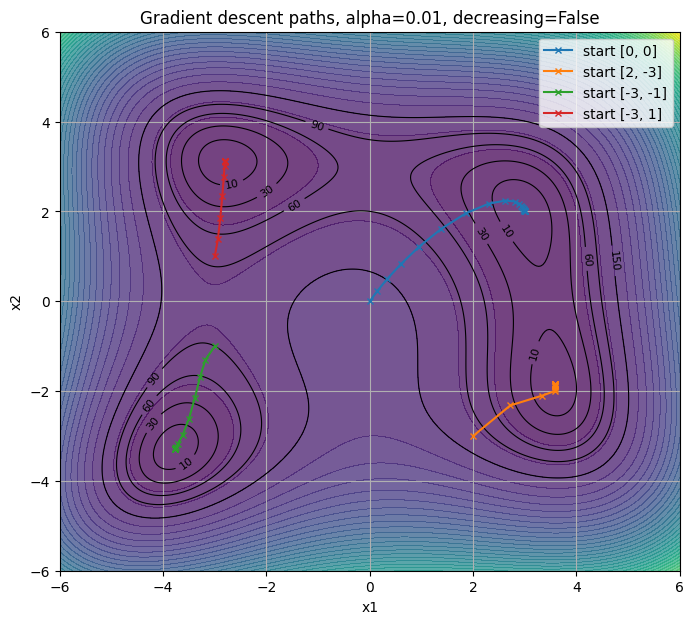

In [11]:
import matplotlib.pyplot as plt

def plot_himmelblau_paths(starting_points, alpha=0.01, decreasing=False):
    """
    Plot contour lines of the Himmelblau function
    and the gradient descent paths.
    """

    # Create grid
    x1_values = np.linspace(-6, 6, 300)
    x2_values = np.linspace(-6, 6, 300)

    X1, X2 = np.meshgrid(x1_values, x2_values)

    Z = (X1**2 + X2 - 11)**2 + (X1 + X2**2 - 7)**2

    plt.figure(figsize=(8, 7))

    # Filled background
    plt.contourf(X1, X2, Z, levels=50, alpha=0.75)

    # Contour lines
    contour_lines = plt.contour(X1, X2, Z, levels=[10, 30, 60, 90, 150], colors="black", linewidths=0.8)
    plt.clabel(contour_lines, inline=True, fontsize=8)

    # Use solver
    solver = GradientDescent(alpha=alpha, tol=1e-6, maxit=2000, decreasing=decreasing)

    for x0 in starting_points:
        x_final, residuals, points = solver.solve(himmelblau_gradient, x0)

        plt.plot(points[:, 0], points[:, 1], marker="x", markersize=4, linewidth=1.5, label=f"start {x0}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Gradient descent paths, alpha={alpha}, decreasing={decreasing}")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_himmelblau_paths(starting_points, alpha=0.01, decreasing=False)

# 9. Compare different step sizes

Now we keep the same starting point:

\[
x^0=(0,0)
\]

and compare different values of \(\alpha\).

A small \(\alpha\) should be safe but slow.  
A large \(\alpha\) may be fast, but it can also become unstable.

In [12]:
alphas = [0.001, 0.005, 0.01, 0.02, 0.03, 0.05]

x0 = [0, 0]

for alpha in alphas:
    print("alpha =", alpha)

    solver = GradientDescent(alpha=alpha, tol=1e-6, maxit=1000)
    x_final, residuals, points = solver.solve(himmelblau_gradient, x0)

    print("Final point:", x_final)
    print("f(final):", himmelblau_value(x_final))
    print("Iterations:", len(residuals))
    print("Final residual:", residuals[-1])
    print("-" * 50)

alpha = 0.001
Final point: [2.99999999 2.00000004]
f(final): 1.9105051861525472e-14
Iterations: 672
Final residual: 9.912621721316513e-07
--------------------------------------------------
alpha = 0.005
Final point: [2.99999999 2.00000004]
f(final): 1.8592495121599288e-14
Iterations: 130
Final residual: 9.77874814316003e-07
--------------------------------------------------
alpha = 0.01
Final point: [2.99999999 2.00000003]
f(final): 1.447548919799405e-14
Iterations: 62
Final residual: 8.62841542790155e-07
--------------------------------------------------
alpha = 0.02
Final point: [3.00000001 2.        ]
f(final): 3.506763477345254e-15
Iterations: 39
Final residual: 7.596729092140582e-07
--------------------------------------------------
alpha = 0.03
Final point: [2.18814443 1.62052146]
f(final): 25.85946713368758
Iterations: 1000
Final residual: 50.30695938933574
--------------------------------------------------
alpha = 0.05
Stopped because the method diverged.
Final point: [ 1.16961

## Observation about step size

Usually we see this behavior:

- Very small \(\alpha\): method works, but needs many iterations.
- Medium \(\alpha\): method works faster.
- Too large \(\alpha\): method can jump too far and may not converge.

This is why choosing the step size is very important in gradient descent.

# 10. Decreasing step size

The exercise also asks us to use

\[
\alpha_k = \frac{\alpha}{\sqrt{k+1}}
\]

This means the step size becomes smaller as the iteration number \(k\) grows.

At the beginning, we take larger steps.  
Later, we take smaller and more careful steps.

In [13]:
# Compare constant step size and decreasing step size

x0 = [0, 0]
alpha = 0.03

solver_constant = GradientDescent(alpha=alpha, tol=1e-6, maxit=2000, decreasing=False)
x_constant, res_constant, points_constant = solver_constant.solve(himmelblau_gradient, x0)

solver_decreasing = GradientDescent(alpha=alpha, tol=1e-6, maxit=2000, decreasing=True)
x_decreasing, res_decreasing, points_decreasing = solver_decreasing.solve(himmelblau_gradient, x0)

print("Constant step size")
print("Final point:", x_constant)
print("f(final):", himmelblau_value(x_constant))
print("Iterations:", len(res_constant))
print("Final residual:", res_constant[-1])

print("\nDecreasing step size")
print("Final point:", x_decreasing)
print("f(final):", himmelblau_value(x_decreasing))
print("Iterations:", len(res_decreasing))
print("Final residual:", res_decreasing[-1])

Constant step size
Final point: [2.18814443 1.62052146]
f(final): 25.85946713368758
Iterations: 2000
Final residual: 50.30695938933574

Decreasing step size
Final point: [2.99999999 2.00000004]
f(final): 1.8705213284772653e-14
Iterations: 142
Final residual: 9.808345488223175e-07


## Observation about decreasing step size

A decreasing step size can make the method more stable.

But it can also become slower near the end, because the step size becomes small.

In simple words:

> Decreasing step size is like running at the beginning and walking carefully near the minimum.

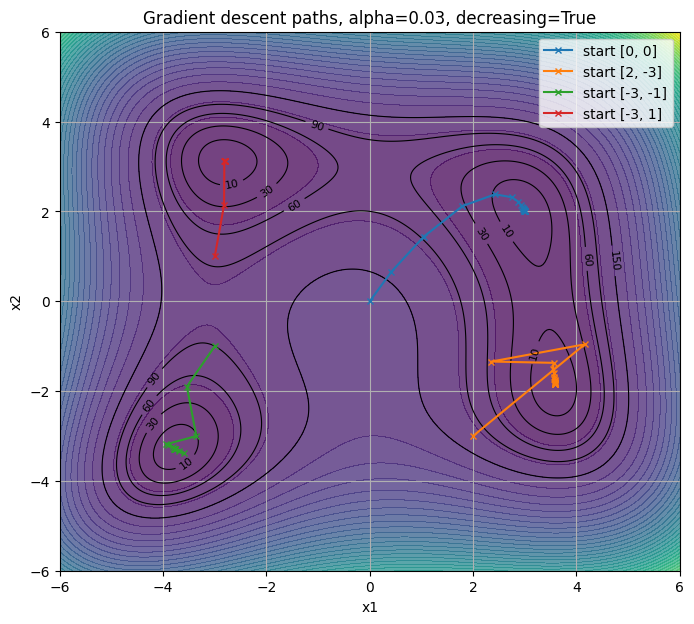

In [14]:
# Plot paths with decreasing step size
plot_himmelblau_paths(starting_points, alpha=0.03, decreasing=True)

# 11. Plot residual over iteration number

The exercise asks for a logarithmic y-axis.

This is useful because the residual often decreases very quickly at first.

We plot:

\[
\|\nabla f(x^k)\|
\]

against iteration number.

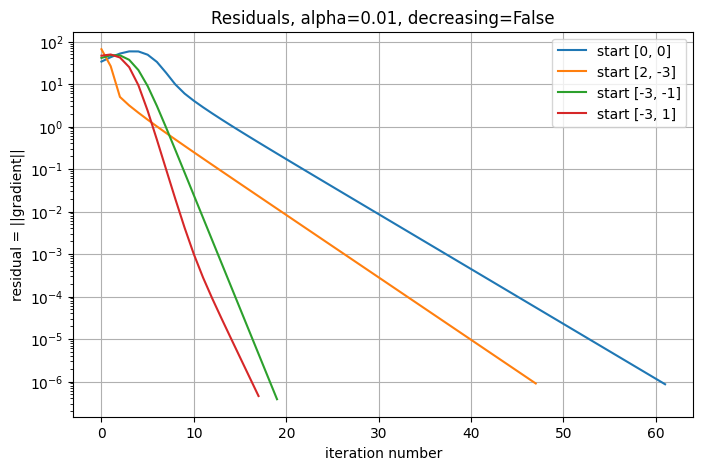

In [15]:
def plot_residuals(starting_points, alpha=0.01, decreasing=False):
    plt.figure(figsize=(8, 5))

    solver = GradientDescent(alpha=alpha, tol=1e-6, maxit=2000, decreasing=decreasing)

    for x0 in starting_points:
        x_final, residuals, points = solver.solve(himmelblau_gradient, x0)

        plt.semilogy(residuals, label=f"start {x0}")

    plt.xlabel("iteration number")
    plt.ylabel("residual = ||gradient||")
    plt.title(f"Residuals, alpha={alpha}, decreasing={decreasing}")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_residuals(starting_points, alpha=0.01, decreasing=False)

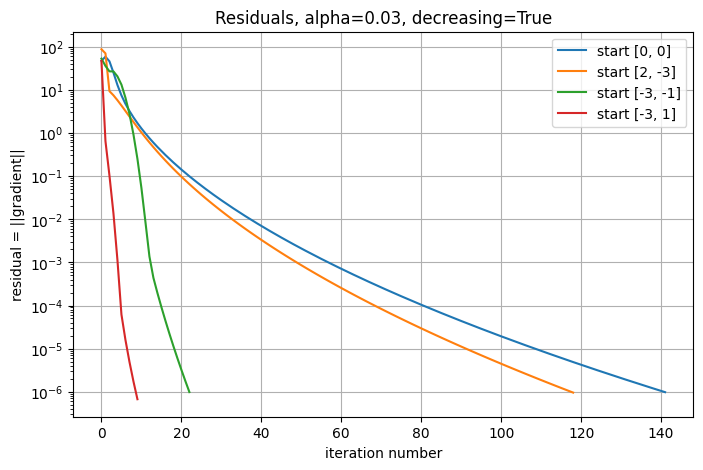

In [16]:
# Residuals for decreasing step size
plot_residuals(starting_points, alpha=0.03, decreasing=True)

# 12. Final answer in words

For \(\alpha = 0.01\), the method converges for the given starting values.

Different starting values reach different minima because the Himmelblau function has several local minima.

When we change \(\alpha\):

- small \(\alpha\) is stable but slow
- good medium \(\alpha\) is faster
- too large \(\alpha\) can make the method unstable or divergent

With decreasing step size

\[
\alpha_k = \frac{\alpha}{\sqrt{k+1}}
\]

the method can become more stable because the steps become smaller during the iteration.

But decreasing step size can also make the method slower near the solution.

# 13. Small practice exercises

Try these after understanding the notebook.

## Exercise A

Change the starting point to

\[
x^0 = (5,5)
\]

Where does the method go?

## Exercise B

Use

\[
\alpha = 0.0005
\]

What happens to the number of iterations?

## Exercise C

Use

\[
\alpha = 0.1
\]

Does the method converge?

## Exercise D

Try decreasing step size with

\[
\alpha = 0.05
\]

Is it more stable than a constant step size?